In [1]:
import os
import sys
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.sparse as sp
import scipy.io as sio
import pickle
from scipy import sparse
sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

In [2]:

# 三组织路径
# tissues = {
#     "skin.late.anagen":  {"path": data_path + "skin/process/",  "color": "#E41A1C", "genome": "mm10"},
#     "brain": {"path": data_path + "brain/process/", "color": "#377EB8", "genome": "mm10"},
#     "lung":  {"path": data_path + "lung/process/",  "color": "#4DAF4A", "genome": "mm10"},
# }

traj = 'brain'
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/case3/data/process/"
data_path = data_root + traj + "/process/"

adata_rna = ad.read_h5ad(data_path + 'rna_processed.h5ad')
adata_atac = ad.read_h5ad(data_path + 'atac_processed.h5ad')
adata_atac.var_names = adata_atac.var_names.str.replace(':', '-', regex=False)


## processed umap

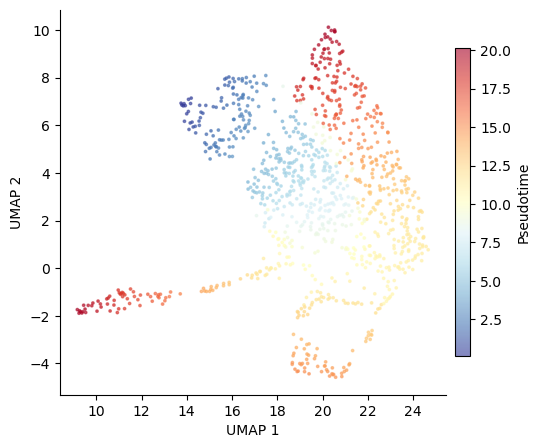

In [3]:
import matplotlib.pyplot as plt

umap_coords = adata_rna.obsm['X_umap'] 
pseudotime = adata_rna.obs['pseudotime'].values

fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    umap_coords[:, 0], umap_coords[:, 1],
    c=pseudotime, cmap='RdYlBu_r',
    s=3, alpha=0.6, rasterized=True
)
fig.colorbar(sc, ax=ax, label='Pseudotime', shrink=0.8, pad=0.02)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.spines[['top','right']].set_visible(False)


## processed pseudotime

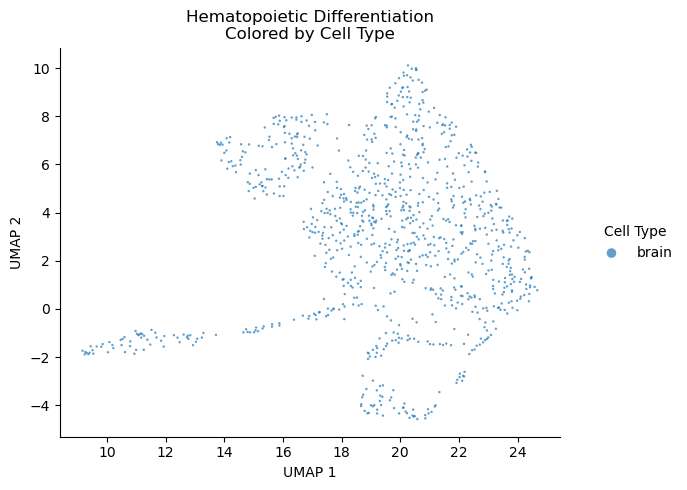

In [4]:
# 1. 提取坐标和细胞类型数据
umap_coords = adata_rna.obsm['X_umap']
cell_types = adata_rna.obs['cell_type']  # 假设列名是 'cell_type'

unique_cell_types = cell_types.unique()

cmap = plt.get_cmap('tab20')
color_dict = {ct: cmap(i / len(unique_cell_types)) for i, ct in enumerate(unique_cell_types)}

fig, ax = plt.subplots(figsize=(7, 5))  

for ct in unique_cell_types:
    mask = (cell_types == ct)
    ax.scatter(
        umap_coords[mask, 0], umap_coords[mask, 1],
        color=color_dict[ct],     # 指定颜色
        label=ct,                 # 指定图例名称
        s=3, alpha=0.7, rasterized=True, edgecolors='none'
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Hematopoietic Differentiation\nColored by Cell Type')
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), # 放在右侧外部
    frameon=False, 
    title='Cell Type',
    markerscale=4 
)

plt.tight_layout()

## Pseudotime distribution

/tmp/ipykernel_22435/3689834955.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


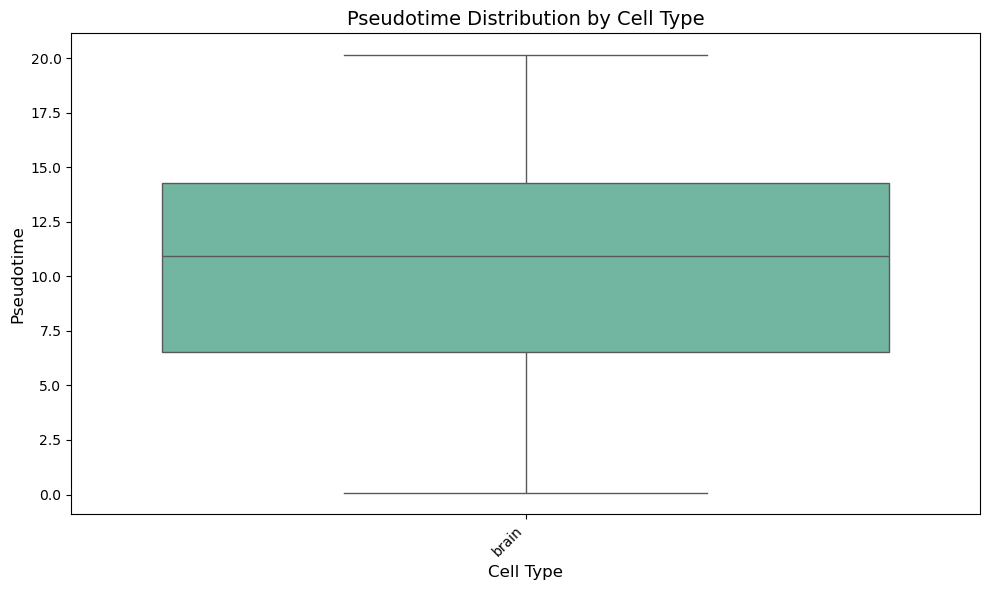

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置画布大小，确保有足够的空间展示所有的类别（可根据类别数量自行调整）
plt.figure(figsize=(10, 6))

# 2. 绘制箱线图
# 直接将 adata_rna.obs 传给 data 参数
sns.boxplot(
    data=adata_rna.obs, 
    x="cell_type",      # X轴：细胞类型
    y="pseudotime",     # Y轴：伪时间
    palette="Set2"      # 使用一个柔和的调色板（可选参数）
)

# 3. 美化图表
plt.title("Pseudotime Distribution by Cell Type", fontsize=14)
plt.xlabel("Cell Type", fontsize=12)
plt.ylabel("Pseudotime", fontsize=12)

# 如果你的细胞类型名称（如 "ID2-hi myeloid prog"）比较长，
# 建议旋转 X 轴标签，防止文字相互重叠看不清
plt.xticks(rotation=45, ha="right")

# 自动调整子图参数，使之填充整个图像区域
plt.tight_layout() 

# 4. 显示（或保存）图像
plt.show()
# 如果你想保存到本地，可以把 plt.show() 替换为：
# plt.savefig("pseudotime_boxplot.pdf", dpi=300)

# Test

          TF                      Peak    score   p-value  q-value     value
75201   RORA     chr10-8781972-8782471  17.2921  0.000002    0.924  5.798603
75205     Ar   chr17-28517870-28518369  16.4483  0.000002    0.420  5.798603
75206     Ar   chr18-61535487-61535986  16.4483  0.000002    0.420  5.798603
75208   Spi1  chr8-105170301-105170800  16.1789  0.000002    0.108  5.798603
75209  GLIS3   chr13-74010620-74011119  14.7541  0.000002    0.391  5.798603
                     Peak           Gene         ts   predict
0  chr5-63649823-63650322  0610040J01Rik   6.620562  0.656098
1  chr5-63649823-63650322  0610040J01Rik  14.805142  0.902573
2  chr5-63649823-63650322  0610040J01Rik  18.310387  0.330987
3  chr5-63649823-63650322  0610040J01Rik  12.943382  0.921845
4  chr5-63649823-63650322  0610040J01Rik  19.782632  0.924230
                       Peak   Gene  avg_ts_weight  avg_total_weight  predict  \
0    chr1-10037813-10038312   Sgk3       0.779127         29.606836        0   
1    c

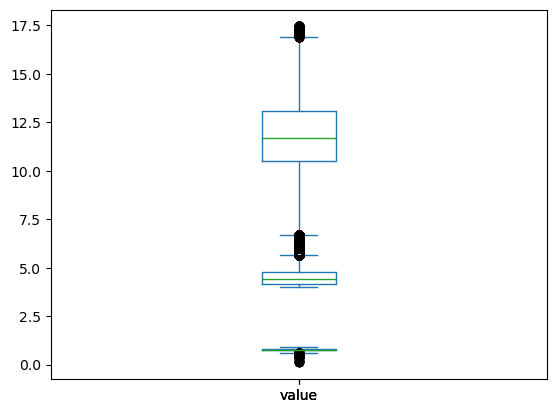

In [6]:

#########################################################################################################
# # ------------------------------------------ TF-Peak ---------------------------------------------

jaspar_data = pd.read_pickle(data_path + "jaspar_df.pkl")
jaspar_data['sequence_name'] = jaspar_data['sequence_name'].str.replace(':','-')
jaspar_tf_peak = jaspar_data[['TF_Symbol', 'sequence_name', 'score', 'p-value', 'q-value']].copy()
jaspar_tf_peak.rename(columns= {'TF_Symbol': 'TF', 'sequence_name':'Peak'}, inplace = True)
jaspar_tf_peak.drop_duplicates(subset=['TF','Peak'], keep= 'first', inplace= True)
jaspar_tf_peak['value'] = - np.log10(jaspar_tf_peak['p-value'])

jaspar_filter_df = jaspar_tf_peak[jaspar_tf_peak["TF"].isin(set(adata_rna.var_names))]
jaspar_filter_df = jaspar_filter_df[jaspar_filter_df["Peak"].isin(set(adata_atac.var_names))]

score_mask = (jaspar_tf_peak['score']> 6 ) & (jaspar_tf_peak['score']< 17.5 )
value_mask= jaspar_tf_peak['value'] < 5.8
combined_mask = score_mask & value_mask

tf_peak_grn = jaspar_tf_peak[combined_mask].copy()

tf_peak_grn['value'].plot.box()
tf_peak_grn['score'].plot.box()

tf_peak_grn.to_pickle(data_path + 'pred_tf_peak.pkl')

print(tf_peak_grn.head())

# jaspar_tf_peak = jaspar_tf_peak[jaspar_tf_peak['q-value']< jaspar_q_threshold ]
# jaspar_tf_peak = jaspar_tf_peak[jaspar_tf_peak['score']> jaspar_score_threshold]
# mask = (jaspar_tf_peak['value']> jaspar_threshold ) & (jaspar_tf_peak['value']< 8)

# new_jaspar_tf_peak = jaspar_tf_peak.loc[mask,['TF', 'Peak', 'value']].copy()

# new_jaspar_tf_peak.to_pickle(data_path + 'process/pred_tf_peak.pkl')


#########################################################################################################
# ------------------------------------------ Peak-Gene - ---------------------------------------------

total_peak = set(adata_atac.var_names)

Node_id = pd.read_pickle(data_path + "node_id.pkl")
graph_df = pd.read_pickle(data_path + "Graph_df.pkl")
graph_df["Unnamed"] = graph_df.index
name_list = ["Unnamed", "source_node", "target_node", "time", "label", "edge_idx"]
New_Graph = graph_df[name_list].copy()
New_Graph.columns = ['Unnamed: 0', 'u', 'i', 'ts', 'label', 'idx']

result_path = data_path + 'my_result_run0.npy'
predict_edge_label = np.load(result_path)

# binary_output = (predict_edge_label > 0.5).astype(int)
New_Graph["predict"] = predict_edge_label
dyg_predict_grn = New_Graph.copy()

mapping_series = Node_id["name"]
dyg_predict_grn['source'] = (dyg_predict_grn['u'] - 1).map(mapping_series)
dyg_predict_grn['target'] = (dyg_predict_grn['i'] - 1).map(mapping_series)

dyg_peak_gene_df = dyg_predict_grn[['source', 'target', 'ts','predict']].rename(
    columns={'source': 'Peak', 'target': 'Gene'}
)
dyg_peak_gene_df = dyg_peak_gene_df[~dyg_peak_gene_df["Gene"].str.startswith('chr')].copy()

dyg_peak_gene_df['Peak'] = dyg_peak_gene_df['Peak'].str.replace(':', '-', regex=False)
    
####################################################################################

avg_active_peak_gene_grn = dyg_peak_gene_df.groupby(['Peak', 'Gene']).agg(
    avg_ts_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

avg_active_peak_gene_grn = avg_active_peak_gene_grn[avg_active_peak_gene_grn["Peak"].isin(total_peak)].copy()
avg_active_peak_gene_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)
avg_active_peak_gene_grn.dropna()

avg_active_peak_gene_grn["predict"] = (avg_active_peak_gene_grn["avg_ts_weight"]> 0.95).astype(int)

avg_active_peak_gene_grn["value"] = avg_active_peak_gene_grn["avg_ts_weight"]
avg_active_peak_gene_grn['value'].plot.box()

dyg_peak_gene_df.to_pickle(data_path + "pred_time_peak_gene.pkl")
avg_active_peak_gene_grn.to_pickle(data_path + "pred_peak_gene.pkl")

print(dyg_peak_gene_df.head())
print(avg_active_peak_gene_grn.head())


#########################################################################################################
# # ------------------------------------------ TF-Gene ---------------------------------------------

##################################################################
########################################################################################
# load tf-region data

tf_peak_grn = pd.read_pickle(data_path + 'pred_tf_peak.pkl')

########################################################################################
# load dygmamba data 
dyg_peak_gene_grn = pd.read_pickle(data_path + "pred_time_peak_gene.pkl")
dyg_peak_gene_grn = dyg_peak_gene_df[dyg_peak_gene_df["Peak"].isin(total_peak)]

pred_peak_gene_grn = pd.read_pickle(data_path + "pred_peak_gene.pkl")


#################################################################################### 
# get tf-gene network

merged_df = pd.merge(tf_peak_grn, dyg_peak_gene_grn, on='Peak')

tf_gene_grn = merged_df.groupby(['TF', 'Gene', 'ts']).agg(
    peak_num=('Peak', 'nunique'),   # 对 Peak 列做去重计数，新列名叫 peak_num
    avg_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

#################################################################################### 
# get average tf-gene network

pred_tf_gene_grn = tf_gene_grn.groupby(['TF', 'Gene']).agg(
    avg_ts_weight=('total_weight', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('total_weight', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

tf_gene_grn.to_pickle(data_path + "pred_time_tf_gene.pkl")
pred_tf_gene_grn.to_pickle(data_path + "pred_tf_gene.pkl")

print(pred_tf_gene_grn.head())
